**Name:** Keith Hamilton

**Student ID:** 24360627

## **E-tivity 3: Convolutional Neural Networks (CNNs)**

In this E-tivity, we will be introducing the ideas behind Convolutional Neural Networks (CNNs), and do a little bit of hands-on work to showcase why they are such a good fit for image data.

In the first few parts of the E-tivity, we will be looking at some basic concepts and operations that CNNs rely on. We will look at images as numbers, the convolution operation, as well as the concept of pooling.

In the final part, we will introduce the [Keras deep learning framework](https://www.tensorflow.org/api_docs/python/tf/keras) which is a high level framework that will allow you to implement CNNs with minimal code. You can see that this implementation is part of tensorflow. The documentation is for the latest TF version but even if you do not have that, the functions should work the same. We will leave our manual implementations behind and use Keras to train and test a small CNN that can identify cats and dogs.

It is not expected that you have any previous knowledge of convolutions or deep learning networks, as we will try to develop some hands-on understanding. It is important however, that you already understand the idea behind traditional Artificial Neural Networks (as seen in E-tivity 2) as CNNs are very closely related and use the same approach to model training.

Note that this notebook requires more modules than the previous ones, so even if you don't intend to get started straight away on the code, try and spare some time just to install the required modules as this may spare you some time when you want to get coding down the line.

- **Tasks 1-4** are group tasks. The notebook can be shared and help solicited from the forum.
- **Task 5** is an individual task. Your shared notebook should not contain any code relating to task 5 and there should be no posts on the forum about task 5.

Grading guidelines: 

https://learn.ul.ie/d2l/lp/rubrics/preview.d2l?ou=68444&rubricId=3433&originTool=quicklinks


Add additional cells to the notebook, if needed, in the appropriate place. Marks will be deducted if the notebook cannot be executed using "Run All".

**To complete the e-tivity upload this notebook to Brightspace with all the tasks completed. Do not push task 5 to the locker.**


## **Setting up the Python environment**

You will need to install a bunch of modules for this E-tivity. While you're likely to already have numpy and matplotlib, you may need to install 'imageio' as well as 'tensorflow'. Perhaps the easiest way to install python packages is to use 'pip'. Additionally, you will likely need the 'pillow' module, which is a popular fork of the Python Imaging Library (PIL) for Keras image preparation.

**Make sure you have TF version >= 2.7.**

If you can run the following cell, then you should be fine:

In [183]:
import sys
print(sys.version)


3.11.5 (main, Sep 11 2023, 13:54:46) [GCC 11.2.0]


In [184]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import imageio.v2 as imageio    # (avoids warnings)
import PIL # actually from the 'pillow' package

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.utils import image_dataset_from_directory, load_img

In [185]:
import tensorflow as tf
print(tf.__version__)

2.16.1


## CNNs, a brief introduction

We'll have a look at an important class of Deep Learning models known as Convolution Neural Networks, which amongst other things have led to great strides in image analysis and computer vision. Machine Learning has long been used for image analysis, specifically for feature detection or image classification:
- Optical Character Recognition (OCR)
- Handwriting recognition
- Automated image tagging
- Facial recognition

In particular, Artificial Neural Networks (ANN) have been routinely used for that purpose. The feed-forward approach has limits that CNNs have overcome using an idea from more traditional methods. The core idea is to apply a moving window filter to input data, that will be trained to extract small features (lines, curves, etc). These feature maps are then used to train the network with more filters to recognise bigger features (squares, triangles, circles, longer lines, etc) composed from the smaller ones. Finally, like in a traditional ANN, fully connect all the resulting data into a dense network and calculate outputs. The *convolution filters*, like the connections between neurons in the dense layers, are represented by a set of weights that will be adjusted through the training process, by minimising a loss function. This should sound familiar to you by now!

Note that while this approach is a natural fit for computer vision type problems and image classification is the most intuitive way to understand CNNs. However it is a generic Deep Learning architecture fit for many purposes: convolutions are just a tool to detect specific patterns from multidimensional numerical arrays, whether these represent images, time series or text. But since they are a great fit for images, this will be our use case for this E-tivity. Images make for a visually impressive demonstration of the power of the convolution operator, and they are more entertaining to work with than the functions and dots you have dealt with so far.

As an idea of the kind of tasks these models can accomplish, you may look at the [ImageNet database](http://www.image-net.org/) which contains images classified across over 20000 categories that include things such as strawberry, mayor or yo-yo. Modern CNN models (well, *enriched* CNNs) achieve less than 5% error in classification these days, to the point where ImageNet is no longer complex enough a task for AI and a 3d database of objects described through natural language is currently being developed as a new challenge.

## **Task 1: Images as numbers**

### Introduction
So far, we only ever dealt with numbers, but now, we want to deal with images. Thankfully, as far as the computer's concerned, digital images are numbers:
- At its core, an image is a numerical matrix, containing the colour values of each pixel at any given x/y coordinates.
- For a greyscale image, that number is the intensity of the pixel on a given scale: say 0 for pure black, 255 for pure white, and a number of grey shades in-between. Using floating point numbers, the scale could be between 0 (black) and 1 (white) instead. For example, this would be how the computer sees a 7 by 7 pixels black image with a white square outline:

$$\begin{vmatrix}
0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 255 & 255 & 255 & 255 & 255 & 0 \\
0 & 255 & 0 & 0 & 0 & 255 & 0 \\
0 & 255 & 0 & 0 & 0 & 255 & 0 \\
0 & 255 & 0 & 0 & 0 & 255 & 0 \\
0 & 255 & 255 & 255 & 255 & 255 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 \\
\end{vmatrix}$$

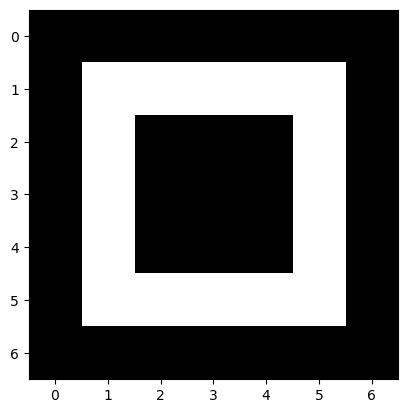

In [186]:
# let's define that simple figure as a matrix and plot it

# This is an empty white square on a black background.

plt.imshow(

    np.array(
    [[ 0,   0,   0,   0,   0,   0, 0 ],
     [ 0, 255, 255, 255, 255, 255, 0 ],
     [ 0, 255,   0,   0,   0, 255, 0 ],
     [ 0, 255,   0,   0,   0, 255, 0 ],
     [ 0, 255,   0,   0,   0, 255, 0 ],
     [ 0, 255, 255, 255, 255, 255, 0 ],
     [ 0,   0,   0,   0,   0,   0, 0 ]], dtype='uint8'),
    
    cmap='gray')

plt.show()

- For a colour image using the Red/Green/Blue (RGB) model, each pixel has one value for each colour channel, so you can picture the image as three numerical matrices: one for Red, one for Green, one for Blue. As such, a 7 by 7 pixels blue image with a red square outline would be represented as such:

Red Channel:
$$\begin{vmatrix}
0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 255 & 255 & 255 & 255 & 255 & 0 \\
0 & 255 & 0 & 0 & 0 & 255 & 0 \\
0 & 255 & 0 & 0 & 0 & 255 & 0 \\
0 & 255 & 0 & 0 & 0 & 255 & 0 \\
0 & 255 & 255 & 255 & 255 & 255 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 \\
\end{vmatrix}$$

Green Channel:
$$\begin{vmatrix}
0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 \\
\end{vmatrix}$$

Blue Channel:
$$\begin{vmatrix}
255 & 255 & 255 & 255 & 255 & 255 & 255 \\
255 & 0 & 0 & 0 & 0 & 0 & 255 \\
255 & 0 & 255 & 255 & 255 & 0 & 255 \\
255 & 0 & 255 & 255 & 255 & 0 & 255 \\
255 & 0 & 255 & 255 & 255 & 0 & 255 \\
255 & 0 & 0 & 0 & 0 & 0 & 255 \\
255 & 255 & 255 & 255 & 255 & 255 & 255 \\
\end{vmatrix}$$

So, what does this mean for our neural networks? Well, a black and white image of width $w$ and height $h$ is an array of $w\times h$ numbers. That means that if we design an ANN/CNN with $w\times h$ input nodes, we can feed our image as input, and calculate something from all those pixel values. For an RGB image, we'll need 3 times more input nodes.

### Coding tasks

- Complete the first two code cells below (replace the '???' blocks) by defining the 'red', 'green' and 'blue' variables so that executing the code produces the respective images:
 - an empty red square on a blue background
 - an empty yellow square on a pink/purple background (read up on the concept of [additive colour](https://en.wikipedia.org/wiki/Additive_color) if you are unfamiliar with it)
- Then plot the sum and difference of these images.
- Can you explain why the sum and difference you just plotted look like they do? Consider the fact that images are composed of unsigned integers (positive only).

#### Creating an empty red square on a blue background

Empty red square on blue background:


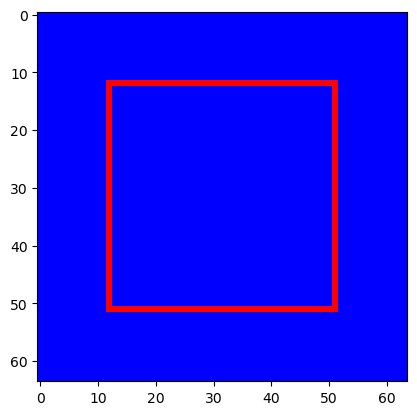

In [187]:
#Task 1: Images as numbers

### Drawing an empty red square on a blue background
# define our R/G/B channels, combine them into a 3d array and plot them

# The image is 64x64 pixels
# Each channel represents colour intensity: 0=dark, 255=bright
H, W = 64, 64

red = np.zeros((H, W), dtype='uint8')

# No green actually needed in image at all
green = np.zeros((H, W), dtype='uint8')

# Blue background is fully on (255 = pure blue)
blue = np.full((H, W), 255, dtype='uint8')


# Calculate where the square should go
# top/left/bottom/right with the border coordinates
# Draw empty red square
square_size = 40
top = (H - square_size) // 2
left = (W - square_size) // 2
bottom = top + square_size
right = left + square_size


# Draw the red outline by setting only the border pixels to 255
# Inside remains zero so the square is empty
# Top and bottom edges
red[top, left:right] = 255
red[bottom-1, left:right] = 255

# Left and right edges
red[top:bottom, left] = 255
red[top:bottom, right-1] = 255

# Turning off blue where the red outline is, so the outline is pure red and not pink
blue[red == 255] = 0

# Stack into RGB image
# np.dstack stacks them along a 3rd dimension
rsq_blue = np.dstack([red, green, blue])

print("Empty red square on blue background:")
plt.imshow( rsq_blue )
plt.show()

Empty yellow square on pink background:


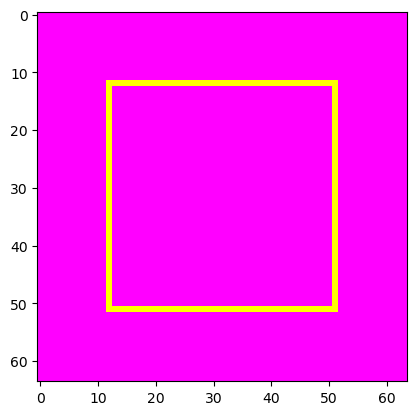

In [188]:
### Drawing an empty yellow square on a pink/purple background
# define our R/G/B channels, combine them into a 3d array and plot them


# Yellow = (255, 255, 0)
# Pink background: mix of red + blue (no green)
red = np.full((H, W), 255, dtype='uint8')  

green = np.zeros((H, W), dtype='uint8')

blue = np.full((H, W), 255, dtype='uint8')

# Draw empty yellow square (outline only)
square_size = 40
top = (H - square_size) // 2
left = (W - square_size) // 2
bottom = top + square_size
right = left + square_size

# Yellow outline: R=255, G=255, B=0
red[top, left:right] = 255
green[top, left:right] = 255

red[bottom-1, left:right] = 255
green[bottom-1, left:right] = 255

red[top:bottom, left] = 255
green[top:bottom, left] = 255

red[top:bottom, right-1] = 255
green[top:bottom, right-1] = 255

# Turning off blue channel where the yellow outline is, so the outline is pure yellow
blue[green == 255] = 0

ysq_pink = np.dstack([red, green, blue])

print("Empty yellow square on pink background:")
plt.imshow( ysq_pink )
plt.show()

Sum of the two images:


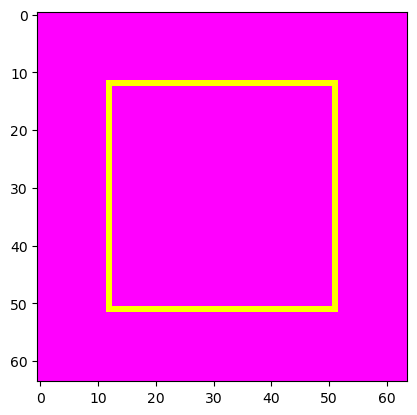

[[[255   0 254]
  [255   0 254]
  [255   0 254]
  ...
  [255   0 254]
  [255   0 254]
  [255   0 254]]

 [[255   0 254]
  [255   0 254]
  [255   0 254]
  ...
  [255   0 254]
  [255   0 254]
  [255   0 254]]

 [[255   0 254]
  [255   0 254]
  [255   0 254]
  ...
  [255   0 254]
  [255   0 254]
  [255   0 254]]

 ...

 [[255   0 254]
  [255   0 254]
  [255   0 254]
  ...
  [255   0 254]
  [255   0 254]
  [255   0 254]]

 [[255   0 254]
  [255   0 254]
  [255   0 254]
  ...
  [255   0 254]
  [255   0 254]
  [255   0 254]]

 [[255   0 254]
  [255   0 254]
  [255   0 254]
  ...
  [255   0 254]
  [255   0 254]
  [255   0 254]]]
Difference of the two images (raw uint8 – mostly clipped to black):


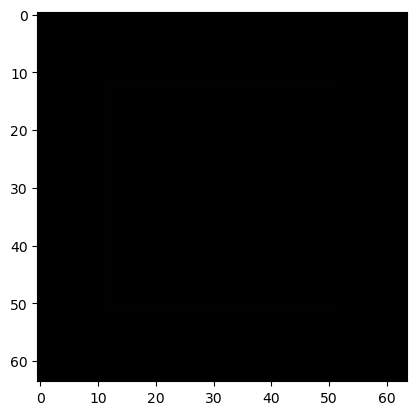

[[[1 0 0]
  [1 0 0]
  [1 0 0]
  ...
  [1 0 0]
  [1 0 0]
  [1 0 0]]

 [[1 0 0]
  [1 0 0]
  [1 0 0]
  ...
  [1 0 0]
  [1 0 0]
  [1 0 0]]

 [[1 0 0]
  [1 0 0]
  [1 0 0]
  ...
  [1 0 0]
  [1 0 0]
  [1 0 0]]

 ...

 [[1 0 0]
  [1 0 0]
  [1 0 0]
  ...
  [1 0 0]
  [1 0 0]
  [1 0 0]]

 [[1 0 0]
  [1 0 0]
  [1 0 0]
  ...
  [1 0 0]
  [1 0 0]
  [1 0 0]]

 [[1 0 0]
  [1 0 0]
  [1 0 0]
  ...
  [1 0 0]
  [1 0 0]
  [1 0 0]]]
Difference of the two images (visualised properly):
[[[-255    0    0]
  [-255    0    0]
  [-255    0    0]
  ...
  [-255    0    0]
  [-255    0    0]
  [-255    0    0]]

 [[-255    0    0]
  [-255    0    0]
  [-255    0    0]
  ...
  [-255    0    0]
  [-255    0    0]
  [-255    0    0]]

 [[-255    0    0]
  [-255    0    0]
  [-255    0    0]
  ...
  [-255    0    0]
  [-255    0    0]
  [-255    0    0]]

 ...

 [[-255    0    0]
  [-255    0    0]
  [-255    0    0]
  ...
  [-255    0    0]
  [-255    0    0]
  [-255    0    0]]

 [[-255    0    0]
  [-255    0    0]
  

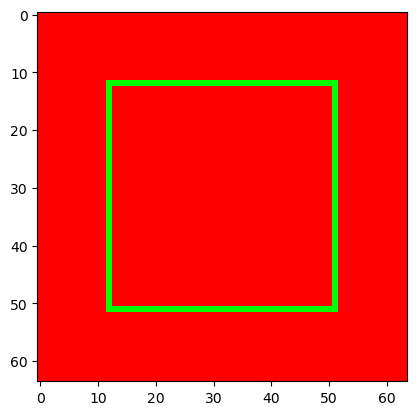

In [189]:
### Plotting the sum and difference of the images

print("Sum of the two images:")
plt.imshow( rsq_blue + ysq_pink )
plt.show()
print(rsq_blue + ysq_pink)

print("Difference of the two images (raw uint8 – mostly clipped to black):")
plt.imshow( rsq_blue - ysq_pink )
plt.show()
print(rsq_blue - ysq_pink)


print("Difference of the two images (visualised properly):")

# Convert to signed integers so negatives don’t wrap around
diff = rsq_blue.astype(np.int16) - ysq_pink.astype(np.int16)
# Print raw numeric differences
print(diff)

# Visualise absolute differences and brighten them
vis = np.abs(diff) * 5        # scale factor (5 or 10 works)
vis = np.clip(vis, 0, 255).astype('uint8')

plt.imshow(vis)
plt.show()


### **Summary: Task 1**

In this task I created two synthetic RGB images using NumPy. Each image is stored as a 3-channel array of shape **(64, 64, 3)** containing unsigned integers between 0 and 255. The first image has a solid blue background with an empty red square drawn by setting the border pixels of the red channel to 255.

The second image uses a purple/pink background (red + blue, no green) and an empty yellow square (yellow = red + green). Again, only the border pixels were edited to create the outline.

For the **sum** image, I add the two RGB images pixel-wise. Because the pixel values are stored as 8-bit unsigned integers in the range [0, 255], any channel value above 255 is **clipped** to 255 when displayed. This means very bright colours (like combining a bright blue background with a pink/purple one) get clipped instead of going beyond 255.

If I subtracted the images directly while keeping them as `uint8`, any negative result would underflow and be clipped up to 0, so most differences would just look black. To avoid that, I converted both images to a signed integer type (`int16`), computed the difference, and then visualised the **absolute** difference (scaled and clipped back into [0, 255]). This makes areas where the two images differ appear bright, while identical regions stay dark.

Overall, this task shows that images are ultimately just collections of numbers, and basic arithmetic operations such as addition and subtraction already create meaningful visual effects like blending (sum) and difference-highlighting (abs-difference).


## **Task 2: The convolution operation**

### Introduction

Think of a simple perceptron where all input nodes are connected to a single output node, with no hidden layer. How many weights would we need to optimise to classify small images of 100 by 100 pixels? Well, since we have one input node per pixel and each input node will only require a single weight (only one node in the next layer), that's 100\*100, so 10000 weights. That is for a single output node, with no hidden layers... That's a lot of weights for a very limited network topology that won't be able to pickup many patterns. This is where convolutions come in.

In our context, the convolution operation is a simple operation based on a source image (actually it's numerical matrix representation) $I$ and a smaller matrix $K$ called a *convolution kernel*. We will drag that kernel across every $(i,j)$ pixel of the source image, and do an elementwise multiplication between the $I$ and $K$ terms before summing up all the terms. The result will be the value of the $(i,j)$ element in our result, called an *activation map*.

**Example:** say we have the following 5x5 pixel grid
$$\begin{vmatrix}
1 & 2 & 3 & 4 & 5\\
6 & 7 & 8 & 9 & 10\\
11 & 12 & 13 & 14 & 15\\
16 & 17 & 18 & 19 & 20\\
21 & 22 & 23 & 24 & 25\\
\end{vmatrix}$$

and we want to calculate the convolved value of the (2,2) pixel that has a value of 7 with the following convolution kernel:

$$\begin{vmatrix}
0 & 1 & 2 \\
1 & 2 & 0 \\
2 & 0 & 0 \\
\end{vmatrix}$$

We match the kernel to the pixel grid so that it is centered over the (2,2) pixel and add the respective kernel/pixel multiplied values:

$$0\times1+1\times2+2\times3+1\times6+2\times7+0\times8+2\times11+0\times12+0\times13=50$$

The convolved value of the (2,2) pixel is therefore 50.

You may notice that we will have a problem calculating values on the edges, since the kernel will be partly outside of the boundaries of the source image. We solve this by either:
- having an activation map that is smaller than the source image (it will be only as big as what we can calculate).
- doing some *padding*: using values of 0 or 1 or something else everywhere we need an out of bounds value.

The figure below illustrates the convolution process over a 4x4 grid of pixel values and a 3x3 convolution kernel, as well as zero-padding:

![Applying a convolution kernel. The bottom example illustrates zero-padding to allow edge values to be calculated.](images/convolution.png)

### Coding tasks

The test below loads a RGB image (3 channels, each one a 2d array of pixel intensities) as a [numpy n-dimensional array](https://docs.scipy.org/doc/numpy/reference/generated/numpy.ndarray.html) and extracts a single channel. It then calls a convolution function a few times with different kernels before displaying the resulting activation map. You must:
- Implement a generic *Convolve(image,kernel,padding,pad_value)* function that will take any square $n \times n$ kernel with a stride of 1. Be able to add multiple padding columns and rows with a custom value.
- If this is to hard then the functionality can be reduced.
- The minimum functionality should be to implement a $3 \times 3$ kernel with a stride of 1 and no padding.
- Demonstrate its use with different kernels and padding (if applicable).

In [190]:
# convolution function for source 2d array with nxn kernel, 
# with a number of padding rows/columns (can be 0)
# padding pixels = pad_value

def Convolve(image, kernel, padding, pad_value):
    # Convert to float for calculations (to avoid overflow issues)
    img = image.astype(float)
    ker = kernel.astype(float)

    # Kernel must be square (3x3, 5x5, and so on)
    k = ker.shape[0]          # kernel size (assumes square)
    assert ker.shape[0] == ker.shape[1], "Kernel must be square"

    # Flip the kernel horizontally and vertically for true convolution (not correlation)
    ker = np.flipud(np.fliplr(ker))

    # Apply padding (constant pad_value)
    # Padding adds extra rows/columns around the image so edges can be processed
    if padding > 0:
        img = np.pad(
            img,
            pad_width=padding,
            mode='constant',
            constant_values=pad_value
        )

    H, W = img.shape
    
    out_H = H - k + 1
    out_W = W - k + 1

    # Prepare output activation map
    feature_map = np.zeros((out_H, out_W), dtype=float)

    # Slide the kernel over the image one pixel at a time (stride=1)
    # At each (i,j) multiply image patch * kernel element-wise and sum
    for i in range(out_H):
        for j in range(out_W):
            region = img[i:i+k, j:j+k]
            feature_map[i, j] = np.sum(region * ker)
    
    # Store this sum as the activation at position (i,j)
    return feature_map



Source image:
(137, 300)


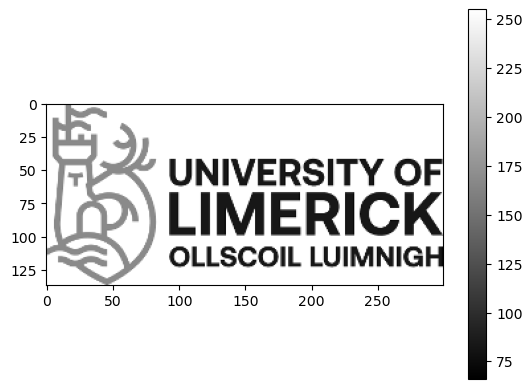

Activation map #1 (kernel 1 - smoothing):
(135, 298)


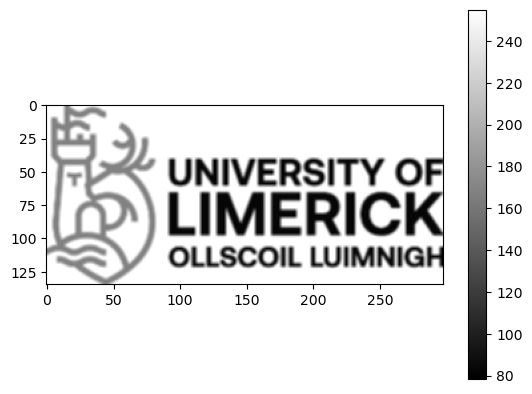

Activation map #2 (kernel 2 - vertical edges):
(135, 298)


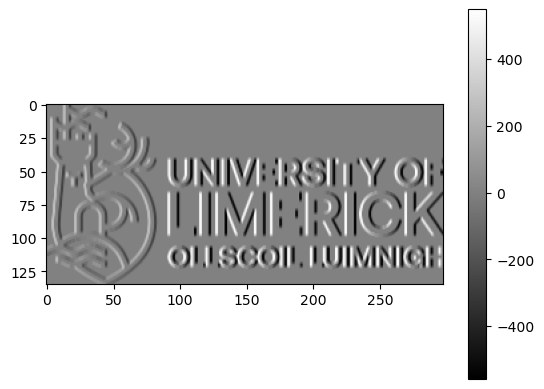

Activation map #3 (kernel 3 - horizontal edges):
(135, 298)


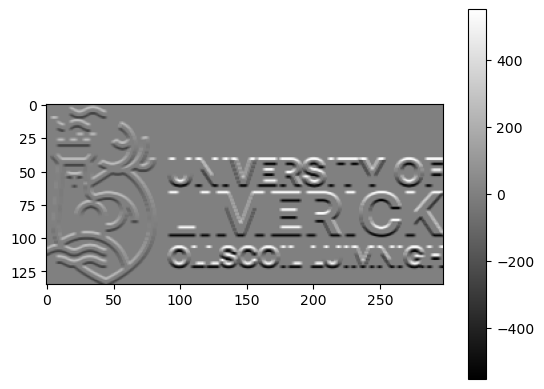

Activation map #4 (kernel 4 - sharpen):
(135, 298)


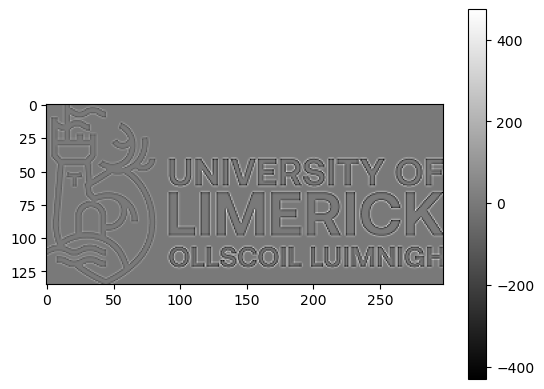

Activation map #5 (kernel 2 then kernel 3):
(133, 296)


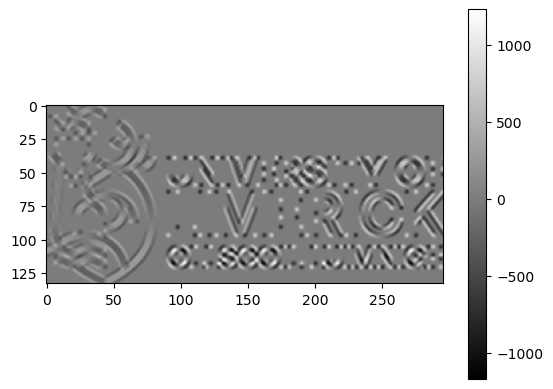

Activation map #6 (kernel 4 with padding=2):
(139, 302)


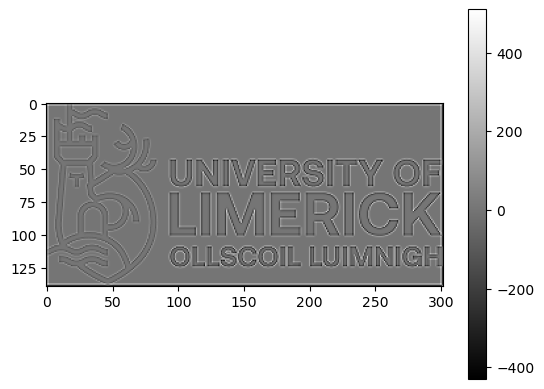

In [191]:
### Test code

def showimage(im):
    plt.imshow(im, cmap='gray')
    plt.colorbar()
    plt.show()
    
 
# read source RGB image as 3 channel image and strip out a single channel
# Loading the UL crest and taking one colour channel - green 
img = imageio.imread('ulcrest_small.png')[:,:,1] # strip out one channel: 0=red, 1=green, 2=blue

print("Source image:")
print(img.shape)
plt.imshow(img, cmap='gray')
plt.colorbar()
plt.show()

# define various 2d convolution kernels

# Kernel 1: smoothing/blurring filter
kernel_1 = np.array(
    [[ .1, .1, .1 ],
     [ .1, .2, .1 ],
     [ .1, .1, .1 ]], dtype='float32')

# Kernel 2: vertical edge detector
kernel_2 = np.array(
    [[ -1,  0,  1 ],
     [ -1,  0,  1 ],
     [ -1,  0,  1 ]], dtype='float32')

# Kernel 3: horizontal edge detector
kernel_3 = np.array(
    [[ -1, -1, -1 ],
     [  0,  0,  0 ],
     [  1,  1,  1 ]], dtype='float32')

# Kernel 4: sharpening filter
kernel_4 = np.array(
    [[  0, -1,  0 ],
     [ -1,  4, -1 ],
     [  0, -1,  0 ]], dtype='float32')



# convolve and display
activationmap_1 = Convolve(img, kernel_1, 0, 0)
print("Activation map #1 (kernel 1 - smoothing):")
print(activationmap_1.shape)
showimage(activationmap_1)

activationmap_2 = Convolve(img, kernel_2, 0, 0)
print("Activation map #2 (kernel 2 - vertical edges):")
print(activationmap_2.shape)
showimage(activationmap_2)

activationmap_3 = Convolve(img, kernel_3, 0, 0)
print("Activation map #3 (kernel 3 - horizontal edges):")
print(activationmap_3.shape)
showimage(activationmap_3)

activationmap_4 = Convolve(img, kernel_4, 0, 0)
print("Activation map #4 (kernel 4 - sharpen):")
print(activationmap_4.shape)
showimage(activationmap_4)

activationmap_5 = Convolve(activationmap_2, kernel_3, 0, 0)
print("Activation map #5 (kernel 2 then kernel 3):")
print(activationmap_5.shape)
showimage(activationmap_5)

# Example with zero-padding so edges are included
activationmap_6 = Convolve(img, kernel_4, padding=2, pad_value=0)
print("Activation map #6 (kernel 4 with padding=2):")
print(activationmap_6.shape)
showimage(activationmap_6)



### **Summary: Task 2 (Convolution)**

In Task 2 I implemented a generic `Convolve(image, kernel, padding, pad_value)` function for 2D images. The function first converts the image and kernel to floating point and checks that the kernel is square. I then flip the kernel horizontally and vertically so that the operation matches the mathematical definition of **convolution** (rather than correlation).

If `padding > 0`, I pad the image on all sides using `np.pad` with a constant `pad_value`. After that, I slide the kernel over every valid (i, j) position with stride 1. At each position I extract a small patch of the image, multiply it element-wise with the kernel and sum the products. This single scalar becomes the corresponding entry in the output **activation map**.

I tested the function on the UL crest image using several standard 3×3 kernels: a smoothing kernel, vertical and horizontal edge detectors, and a sharpening kernel. I also showed how adding padding changes the output shape and allows the filter to respond at the borders. These experiments helped build intuition that a convolution kernel is just a tiny learned filter that looks for local patterns such as edges or corners and writes their “strength” into the activation map.


## **Task 3 Pooling**

### Introduction
We have seen how a small convolution kernel can transform an image into an activation map which highlights specific features. By implementing a number of convolution operations in a neural network before linking up all pixels together in a dense neural net layer, we can therefore train our network to optimise the weights in the convolution kernels so that loss is reduced. This will naturally converge towards kernels that highlight features that significantly correlate with the regression/classification task at hand, and do so efficiently from a computational point of view as we optimise far fewer weights in a convolution layer (only as many as the number of weights required by the kernel) than if we were to connect all pixels to a traditional hidden layer.

Still, at some point, we will want to connect all the pixels from our final activation map together into traditional dense layers (think "hidden layers"). This will still be expensive if the input activation map is too large. It will be even worse if we decide to expand our input into several activation maps, so that different maps capture different features to later correlate together. Also, it won't be generic enough as different weights will need to be optimised to capture the same features in different areas of the image.

In a CNN model, these issues are addressed through *pooling* (also called down-sampling). Pooling consists in reducing chunks of the source data into single data points. Say you take a 2x2 pixel area of the image, and reduce that to a single pixel, using the max value from those 4 pixels as the new value. Then you move that 2x2 window 2 pixels across and repeat the process. When you have done an entire line of the image, you move 2 pixels down and continue, until you're done. What you have done is known as a 2 by 2 (pooling window size) max-pooling (strategy to calculate new value from the ones under the window) operation with a stride of 2 (by how many pixels you shift your window each time).

The following figure illustrates a 2x2 max-pooling with stride 2 over a 4x4 image grid:
![2x2 pooling example with stride 2](images/pooling_stride2.png)

With a stride value equal to the size of the pooling window, all pooled regions are mutually exclusive. By comparison, the following figure illustrates a 2x2 max-pooling with stride 1 over the same image grid, in which case the pooling windows have some intersections:
![2x2 pooling example with stride 1](images/pooling_stride1.png)

In addition to drastically reducing the size of the data, the max-pooling process demonstrated here will be *translation-invariant*. If an activation map has higlighted (high numerical value) a feature in the top left corner of the image, then the top left corner of the pooled image will still carry this high value.

### Coding tasks

The test below calls a pooling function a few times, displaying the resulting pooled image each time. You can use the same original images as previously. You must:

- Implement a generic maxpooling function *Maxpooling(image, h, w, sx, sy)* that with take a kernel of any size $w \times h$ and with independent strides $s_x$ and $s_y$.
- If this is too difficult then the functionality can be reduced. 
- The minimum functionality is a maxpooling layer with $2 \times 2$ kernel with a stride of 2 in both directions.
- Demonstrate it with different kernels and strides (if applicable).

In [192]:
# Max-pooling function for a hxw window size with a stride of sx,sy

def Maxpooling(image, h, w, sh, sw):
    """
    Generic 2D max-pooling:
    Takes an input feature map and reduces each h×w block down to one value
    by keeping only the maximum pixel in the block.
    """

    # Convert to float 
    img = image.astype(float)
    H, W = img.shape

    # Compute output dimensions
    # Ignore any leftover rows/columns that don't fit a full window
    out_H = 1 + (H - h) // sh
    out_W = 1 + (W - w) // sw

    # Create the pooled output map
    feature_map = np.zeros((out_H, out_W), dtype=float)

    # Slide the pooling window across the image
    for i in range(out_H):
        for j in range(out_W):

            # Calculate the top-left corner of the current window (the start)
            top = i * sh
            left = j * sw

            # Get the h×w block from the image
            window = img[top:top + h, left:left + w]

            # Take the maximum value inside the window
            feature_map[i, j] = np.max(window)

    # Return the activation map
    return feature_map




(137, 300)
Source image:
(137, 300)


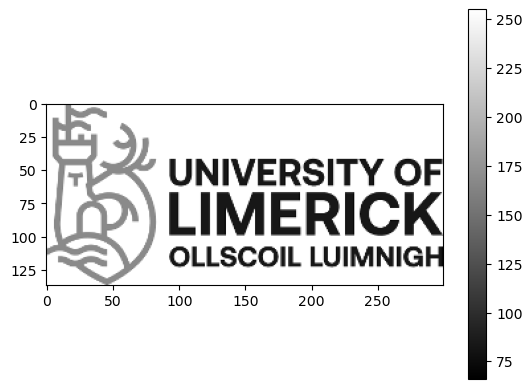

(68, 150)
Pooling #1:


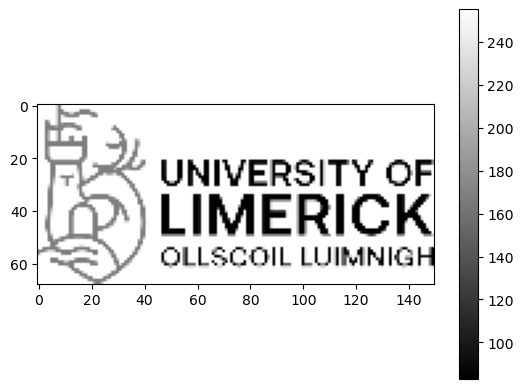

(34, 75)
Pooling #2:


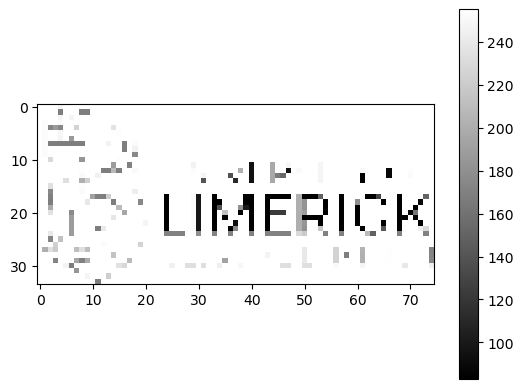

(17, 37)
Pooling #3:


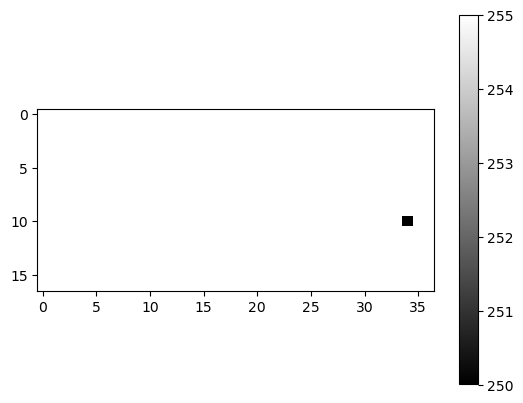

(8, 18)
Pooling #4:


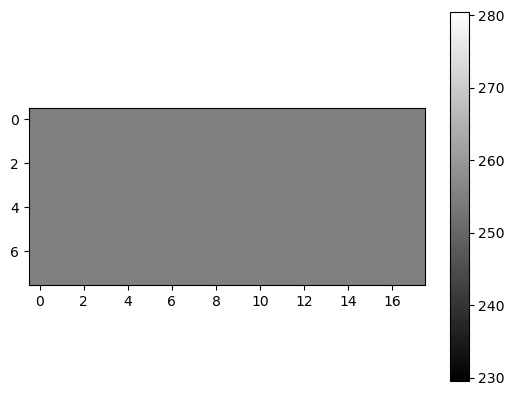

In [193]:
### Test code

# read source RGB image and take a single channel
img = imageio.imread('ulcrest_small.png')[:,:,1]  # 0=red, 1=green, 2=blue


print(img.shape)
print("Source image:")
print(img.shape)
plt.imshow(img, cmap='gray')
plt.colorbar()
plt.show()

# run a few pooling operations and display the result

# Pooling #1: 2×2 window, stride 2 (standard max pooling)
pooled_1 = Maxpooling(img, 2, 2, 2, 2)
print(pooled_1.shape)
print("Pooling #1:")
plt.imshow(pooled_1, cmap='gray')
plt.colorbar()
plt.show()

# Pooling #2: Apply max pooling again to the already pooled output
pooled_2 = Maxpooling(pooled_1, 2, 2, 2, 2)
print(pooled_2.shape)
print("Pooling #2:")
plt.imshow(pooled_2, cmap='gray')
plt.colorbar()
plt.show()

# Pooling #3: One more round to show progressive downsampling
pooled_3 = Maxpooling(pooled_2, 2, 2, 2, 2)
print(pooled_3.shape)
print("Pooling #3:")
plt.imshow(pooled_3, cmap='gray')
plt.colorbar()
plt.show()

# Pooling #4: Final round, image becomes very small
pooled_4 = Maxpooling(pooled_3, 2, 2, 2, 2)
print(pooled_4.shape)
print("Pooling #4:")
plt.imshow(pooled_4, cmap='gray')
plt.colorbar()
plt.show()

Pooling #1:
(67, 149)


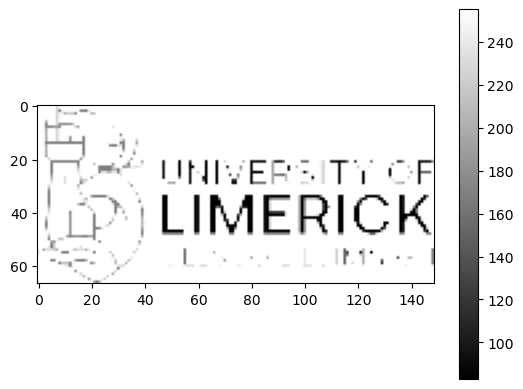

Pooling #2:
(32, 73)


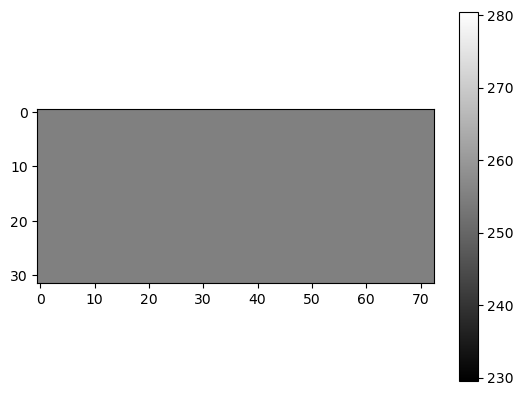

Pooling #3:
(68, 100)


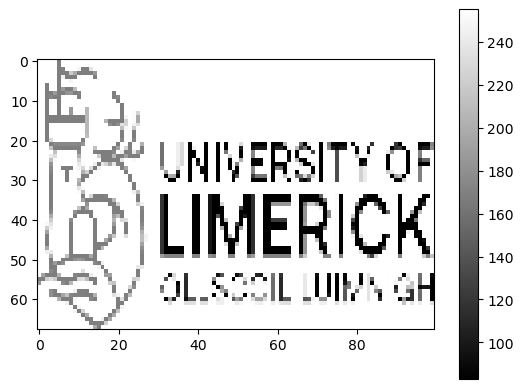

Pooling #4:
(23, 49)


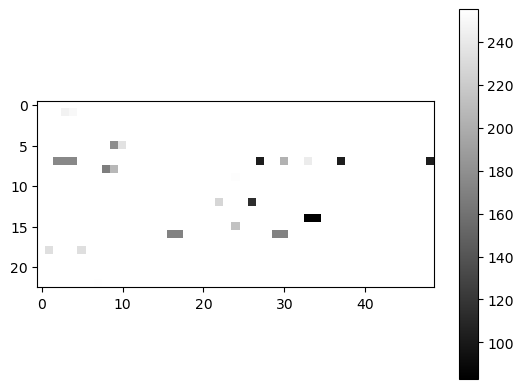

In [194]:
# max pool and display
pooled_1 = Maxpooling(img, 4, 4, 2, 2)
print("Pooling #1:")
print(pooled_1.shape)
plt.imshow(pooled_1, cmap='gray')
plt.colorbar()
plt.show()

pooled_2 = Maxpooling(pooled_1, 4, 4, 2, 2)
print("Pooling #2:")
print(pooled_2.shape)
plt.imshow(pooled_2, cmap='gray')
plt.colorbar()
plt.show()

pooled_3 = Maxpooling(img, 2, 3, 2, 3)
print("Pooling #3:")
print(pooled_3.shape)
plt.imshow(pooled_3, cmap='gray')
plt.colorbar()
plt.show()

pooled_4 = Maxpooling(pooled_3, 2, 3, 3, 2)
print("Pooling #4:")
print(pooled_4.shape)
plt.imshow(pooled_4, cmap='gray')
plt.colorbar()
plt.show()

### **Summary: Task 3 (Max pooling)**

For Task 3 I implemented a generic `Maxpooling(image, h, w, sh, sw)` function. It takes an input feature map and a pooling window of size `h×w` with separate vertical and horizontal strides `sh` and `sw`. First, I compute the output height and width using the standard formula  
`out_H = 1 + (H - h) // sh` and `out_W = 1 + (W - w) // sw`, which effectively ignores any incomplete windows at the image borders.

Inside the nested loops, I calculate the top-left corner of each pooling window as `(i * sh, j * sw)`, slice out that region, and store the **maximum** pixel value in the corresponding position of the output feature map. This keeps only the strongest activation in each local neighbourhood.

I demonstrated the function on the UL crest image using:
- a 2×2 window with stride 2, applied repeatedly, to show how the spatial resolution shrinks at each stage;
- a larger 4×4 window; and
- non-square windows and different stride combinations.

These experiments show how max pooling reduces dimensionality while still preserving where strong features are located, and why pooling helps CNNs become more efficient and more translation-invariant.


## **Task 4: Convolutional Neural Network**

### Introduction
Over the course of the 3 E-tivities in this module, we have looked at all the individual pieces we need to build a convolutional neural network. Convolution layers can transform our input images into activation maps which highlight specific features, pooling allows us to reduce dimensionality while preserving important information in translation-invariant fashion, dense layers allow us to connect all the data together in traditional ANN fashion, and activation functions allow us to add some non-linearity to our model.

Both convolution and dense layers will contain a lot of weights that we will need to optimise, but we have seen how techniques such as gradient descent allow us to do that. Like a traditional ANN, a CNN will be trained through a sequence of forward step, loss calculation, then backward step and weight optimisation.

In these final tasks, we will use the Keras framework to setup a simple CNN topology to train a model to separate images of cats and dogs with minimal code.

Our model will implement the following layers:
- an input layer that accepts 3-channel (RGB) 64x64 images
- a convolution layer with 32 individual 3x3 convolution kernels, and a 'ReLU' activation function
- a 2x2 max-pooling layer with a stride of 2
- a 'flattening' layer that simply transforms our 32 activation maps into a flat numerical vector
- a dense layer (like an ANN hidden layer) with 128 nodes and a 'ReLU' activation function.
- a final dense layer as our output with a single node and a sigmoid activation (binary classification problem).

We will use the adam optimiser, binary crossentropy as a loss function, and we will want accuracy to be shown as a metric.

### Coding Tasks

The following cells contain incomplete Keras code where you will need to complete the '???' sections to get your model defined and trained. Follow the instructions above each cell and complete the code. You will need to consult the Keras documentation. A good starting point would be the [Sequential model guide](https://www.tensorflow.org/api_docs/python/tf/keras/Sequential), and the [Image classification page](https://www.tensorflow.org/tutorials/images/classification).


In [195]:
# define network topology
# Define a simple Sequential CNN model for cat vs dog classification

net = Sequential()

# Input: 64x64 RGB images (3 channels)
net.add(Input(shape=(64, 64, 3)))

# Normalise pixels from [0,255] → [0,1] for stable training
net.add(Rescaling(1./255))

# Convolution layer: 32 filters, 3x3 kernel, ReLU activation
net.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu'))

# Max pooling: 2x2 window, stride 2
net.add(MaxPooling2D(pool_size=(2,2), strides=2))

# Flatten the feature maps (converting the 3D activation maps into a 1D vector)
net.add(Flatten())

# Dense layer with 128 neurons + ReLU (standard ANN layer to combine extracted features)
net.add(Dense(128, activation='relu'))

# Output layer: 1 neuron + sigmoid - outputs a probability (dog vs cat)
net.add(Dense(1, activation='sigmoid'))

# Compile the model with Adam (gradient descent), binary crossentropy (2 classes)
net.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


**Look at the model summary below and the sample size, does it seem resonable?**

In [196]:
net.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_7 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 30752)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │     3,936,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,937,409 (15.02 MB)

 Trainable params: 3,937,409 (15.02 MB)

 Non-trainable params: 0 (0.00 B)

**Cell instructions:** Training and testing data has been prepared in advance, and can be found in the following folders:
- data/catdog/training_set/ contains two folders: cats/ and dogs/ which each contains individual jpeg images to be used for training.
- data/catdog/test_set/ contains two folders: cats/ and dogs/ which each contains individual jpeg images to be used for testing.

We'll use some of the Keras helper packages to turn those image folders into data sets that the model can use for training/testing. Setup the training and test sets with batches of 32. Complete the cell below according to those requirements:

In [197]:
import os
print(os.listdir('data'))
print(os.listdir('data/catdog'))


['catdog']
['training_set', 'cat_or_dog_4.jpg', 'cat_or_dog_3.jpg', 'cat_or_dog_1.jpg', 'cat_or_dog_2.jpg', 'test_set']


In [198]:
import os

print("Current working directory:")
print(os.getcwd())
print("\nContents of this folder:")
print(os.listdir())

print("\nSearching for cat/dog folders...")
for root, dirs, files in os.walk(".", topdown=True):
    for d in dirs:
        if "catdog" in d.lower():
            print("Found folder:", os.path.join(root, d))


Current working directory:
/home/4e90a9da-47b6-4ce6-9a61-b3fbc473355c/ce4031_e-tivity3

Contents of this folder:
['cifar_loss.png', 'Cifar10 (1).ipynb', 'Cifar10.ipynb', '.ipynb_checkpoints', 'cifar_acc.png', 'Untitled.ipynb', 'cifar_acc_aug.png', 'ulcrest_small.png', 'cifar_loss_aug.png', 'data', 'pooling_stride2.png', 'Etivity3_ConvolutionNetworks_24360627.ipynb', 'convolution.png', 'Convolution_test.ipynb', 'data.zip', 'ulcrest_small_greyscale.png', 'pooling_stride1.png', 'images']

Searching for cat/dog folders...
Found folder: ./data/catdog


In [199]:
# training_set loads images and labels them automatically

training_set = image_dataset_from_directory(
    'data/catdog/training_set',
    image_size=(64, 64),
    batch_size=32
)

# Validation (test_set) measures performance on unseen images during training
test_set = image_dataset_from_directory(
    'data/catdog/test_set',
    image_size=(64, 64),
    batch_size=32
)


Found 2404 files belonging to 2 classes.
Found 500 files belonging to 2 classes.


**Cell instructions:** fit your model on the training set over 10 epochs. Include the test set in the fitting process for validation.

In [200]:
hist = net.fit(
    training_set,
    epochs=10,
    validation_data=test_set
)


Epoch 1/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.5670 - loss: 0.7132 - val_accuracy: 0.6540 - val_loss: 0.6528
Epoch 2/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - accuracy: 0.7196 - loss: 0.5610 - val_accuracy: 0.6940 - val_loss: 0.6129
Epoch 3/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - accuracy: 0.7974 - loss: 0.4376 - val_accuracy: 0.7040 - val_loss: 0.6088
Epoch 4/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - accuracy: 0.8606 - loss: 0.3426 - val_accuracy: 0.6740 - val_loss: 0.6244
Epoch 5/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - accuracy: 0.9027 - loss: 0.2634 - val_accuracy: 0.7020 - val_loss: 0.6600
Epoch 6/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 10s 79ms/step - accuracy: 0.9347 - loss: 0.1939 - val_accuracy: 0.6740 - val_loss: 0.8168
Epoch 7/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - accuracy: 0.9634 - loss: 0.1434 - val_accuracy: 0.6420 - val_loss: 1.1696
Epoch 8/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - accuracy: 0.9655 - loss: 0.1213 - val_accuracy: 0.6800 - 

- Below is how you can plot the loss and accuracy using the save stats from the model fitting.

- Possibly you can see that you have an overfitting model.

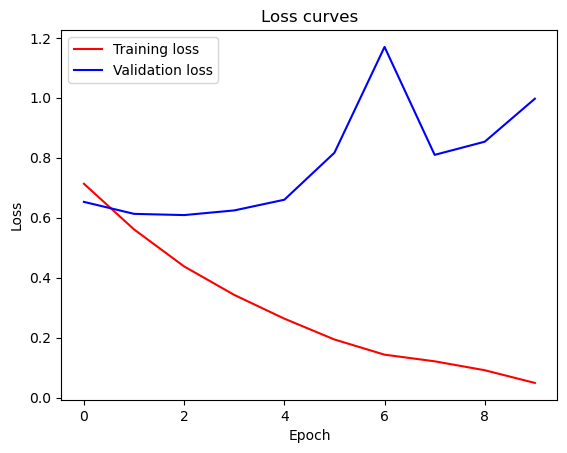

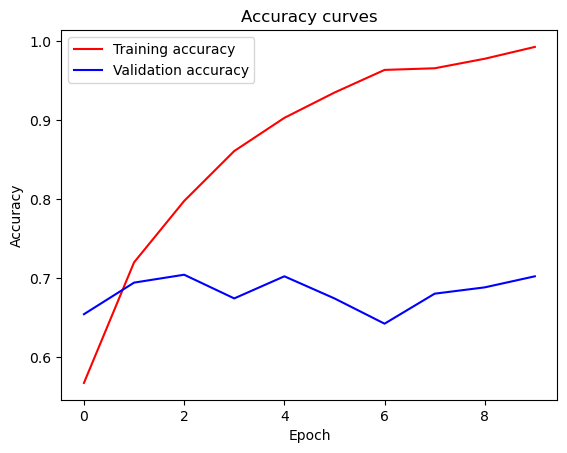

In [201]:
# Training vs validation curves to check for overfitting
# If the red (training) continues improving while the blue (validation) stops improving → overfitting
# Red = training
# Blue = validation

plt.plot(hist.history['loss'], c='r', label='Training loss')
plt.plot(hist.history['val_loss'], c='b', label='Validation loss')
plt.title("Loss curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(hist.history['accuracy'], c='r', label='Training accuracy')
plt.plot(hist.history['val_accuracy'], c='b', label='Validation accuracy')
plt.title("Accuracy curves")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


### **Summary: Task 4 (Baseline CNN on cats vs dogs)**  

For Task 4 I built the simple CNN exactly as described in the brief using Keras: an input layer for 64×64 RGB images, a single Conv2D layer with 32 3×3 filters and
ReLU, a 2×2 max-pooling layer (stride 2), a Flatten layer, a Dense(128, ReLU) hidden layer and a final Dense(1, sigmoid) output for binary classification.
The model was compiled with the Adam optimiser, binary cross-entropy loss and accuracy as the metric.

The model has about 3.9 million trainable parameters, which is quite large compared to the ~2.4k training images. This comes mainly from flattening the
31×31×32 feature maps (after conv + pooling) into a 30,752-dimensional vector and feeding it into a 128-unit dense layer.

I trained the network for 10 epochs on the training_set and used the test_set for validation. Training accuracy increased steadily from ~0.58 up to ~0.99,
while the validation accuracy only improved to around 0.68–0.71 and then flattened. The loss curves show the same pattern: training loss keeps falling
but validation loss bottoms out and then starts to rise again.

Taken together, these curves show that the baseline CNN is clearly overfitting: it fits the training data extremely well but does not generalise as strongly to
the unseen validation images. In Task 5 I will try to adjust the architecture and regularisation to get nearer 70% validation accuracy while reducing this
overfitting behaviour.

Overall, this implements the classic CNN pipeline of **Convolution → MaxPooling → Flatten → Dense → Output**, trained with gradient descent via Adam.


## **Task 5: Individual Task**

You have now trained your first CNN, congratulations! Now experiment with the model topology there are no restrictions on layer types nor how many. Change hyperparameters and use [augmentation](https://www.tensorflow.org/tutorials/images/data_augmentation) to see if you can get towards 70% accuracy without overfitting.

This is quite a hard problem because you have a limited amount of data. However what is important is that you make rational decisions that will move you in that direction. The advise is to make incremental changes to the model and test it. Do not waste too much time trainng the model try 50-100 epochs per experiment.

**Remember do not submit this task to gitlab nor comment on the forum.**

In [202]:
# Extra imports just for Task 5 experiments

from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers
from tensorflow.keras.layers import RandomTranslation


In [203]:
# Simple data augmentation block:
# This randomly flips, rotates and zooms images during training.
# The idea is to show the model slightly different versions of the same image
# each epoch so it generalises better and doesn’t just memorise the training set.

data_augmentation = Sequential([
    RandomFlip("horizontal"),       # sometimes flip left/right (cats and dogs can face either way)
    RandomRotation(0.05),           # small random rotations (~±5%)
    RandomZoom(0.1),                # small random zoom in/out
    RandomTranslation(0.05, 0.05),  # small horizontal & vertical shifts    
], name="data_augmentation")


In [204]:
# Task 5: New CNN model with:
# - Data augmentation
# - Two Conv+Pool blocks
# - Smaller dense layer
# - Dropout and L2 regularisation
# Goal: get ~70% validation accuracy without the training accuracy going to 0.99+

new_model = Sequential(name="catdog_cnn_task5")

# Input: 64x64 RGB images
new_model.add(Input(shape=(64, 64, 3), name="input_image"))

# 1) Rescaling: pixels from [0,255] -> [0,1]
new_model.add(Rescaling(1./255, name="rescale"))

# 2) Data augmentation (only active during training)
new_model.add(data_augmentation)

# 3) First convolution + pooling block
new_model.add(Conv2D(
    filters=32,
    kernel_size=(3, 3),
    activation='relu',
    name="conv_block1"
))
new_model.add(MaxPooling2D(
    pool_size=(2, 2),
    strides=2,
    name="pool_block1"
))

# 4) Second convolution + pooling block
#    This lets the model learn more complex features before flattening,
#    and also reduces the spatial size so the Dense layer has fewer parameters.
new_model.add(Conv2D(
    filters=64,
    kernel_size=(3, 3),
    activation='relu',
    name="conv_block2"
))
new_model.add(MaxPooling2D(
    pool_size=(2, 2),
    strides=2,
    name="pool_block2"
))

# 5) Flatten 3D feature maps -> 1D vector
new_model.add(Flatten(name="flatten"))

# 6) Dense layer with fewer units + L2 regularisation
#    L2 penalises very large weights and encourages a simpler model.
new_model.add(Dense(
    units=64,                        # smaller than 128 from Task 4
    activation='relu',
    kernel_regularizer=regularizers.l2(1e-4),
    name="dense_hidden"
))

# 7) Dropout: randomly drop 50% of the units during training
#    This stops the Dense layer from memorising the training set.
new_model.add(Dropout(0.5, name="dropout"))

# 8) Output layer: 1 neuron with sigmoid -> probability of "dog"
new_model.add(Dense(
    units=1,
    activation='sigmoid',
    name="output"
))

# Compile with Adam and binary cross-entropy, same as baseline
new_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Show the updated architecture and parameter count
new_model.summary()


Model: "catdog_cnn_task5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescale (Rescaling)             │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_block1 (Conv2D)            │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_block1 (MaxPooling2D)      │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_block2 (Conv2D)            │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_block2 (MaxPooling2D)      │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 822,337 (3.14 MB)

 Trainable params: 822,337 (3.14 MB)

 Non-trainable params: 0 (0.00 B)

In [205]:
# Recreate training_set and test_set if starting from a fresh kernel
# (same directories and settings as Task 4)

training_set = image_dataset_from_directory(
    'data/catdog/training_set',
    image_size=(64, 64),
    batch_size=32
)

test_set = image_dataset_from_directory(
    'data/catdog/test_set',
    image_size=(64, 64),
    batch_size=32
)

# Use tf.data performance helpers: cache, shuffle, prefetch
import tensorflow as tf
AUTOTUNE = tf.data.AUTOTUNE

# train_ds: cached, shuffled, and prefetched
train_ds = training_set.cache().shuffle(1000).prefetch(AUTOTUNE)

# val_ds: cached + prefetched (no shuffle needed)
val_ds = test_set.cache().prefetch(AUTOTUNE)


Found 2404 files belonging to 2 classes.
Found 500 files belonging to 2 classes.


In [206]:
# Early stopping callback:
# - Watches validation loss
# - If it doesn’t improve for 'patience' epochs, stop training
# - Restore the best weights seen so far

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,              # wait 5 epochs with no improvement
    restore_best_weights=True,
    verbose=1
)

# Train the new model on the same data, but with early stopping
# Note: 40 is the *max* number of epochs.
# In practice it will usually stop earlier when val_loss stops improving.

hist_task5 = new_model.fit(
    train_ds,
    epochs=40,
    validation_data=val_ds,
    callbacks=[early_stop]
)


Epoch 1/40
76/76 ━━━━━━━━━━━━━━━━━━━━ 11s 104ms/step - accuracy: 0.5220 - loss: 0.7061 - val_accuracy: 0.5000 - val_loss: 0.7136
Epoch 2/40
76/76 ━━━━━━━━━━━━━━━━━━━━ 8s 106ms/step - accuracy: 0.5749 - loss: 0.6833 - val_accuracy: 0.5800 - val_loss: 0.6718
Epoch 3/40
76/76 ━━━━━━━━━━━━━━━━━━━━ 13s 138ms/step - accuracy: 0.6452 - loss: 0.6498 - val_accuracy: 0.5840 - val_loss: 0.6971
Epoch 4/40
76/76 ━━━━━━━━━━━━━━━━━━━━ 18s 99ms/step - accuracy: 0.6564 - loss: 0.6314 - val_accuracy: 0.6220 - val_loss: 0.6596
Epoch 5/40
76/76 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - accuracy: 0.6768 - loss: 0.6281 - val_accuracy: 0.6100 - val_loss: 0.7083
Epoch 6/40
76/76 ━━━━━━━━━━━━━━━━━━━━ 12s 107ms/step - accuracy: 0.6859 - loss: 0.6082 - val_accuracy: 0.6680 - val_loss: 0.6315
Epoch 7/40
76/76 ━━━━━━━━━━━━━━━━━━━━ 10s 130ms/step - accuracy: 0.6934 - loss: 0.5966 - val_accuracy: 0.6220 - val_loss: 0.7306
Epoch 8/40
76/76 ━━━━━━━━━━━━━━━━━━━━ 10s 129ms/step - accuracy: 0.7067 - loss: 0.5764 - val_accuracy

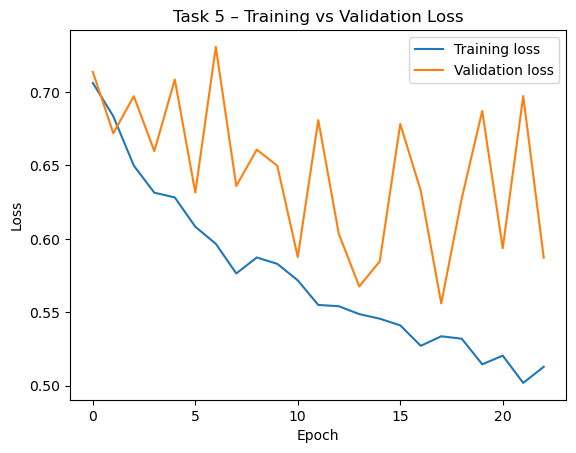

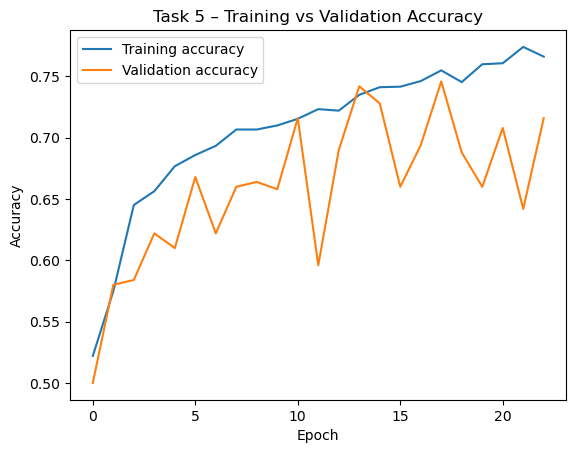

In [207]:
# Plot loss: training vs validation
plt.figure()
plt.plot(hist_task5.history['loss'], label='Training loss')
plt.plot(hist_task5.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Task 5 – Training vs Validation Loss')
plt.legend()
plt.show()

# Plot accuracy: training vs validation
plt.figure()
plt.plot(hist_task5.history['accuracy'], label='Training accuracy')
plt.plot(hist_task5.history['val_accuracy'], label='Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Task 5 – Training vs Validation Accuracy')
plt.legend()
plt.show()


### Visual Test

Below is a more visual test of your model with 4 unseen images.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


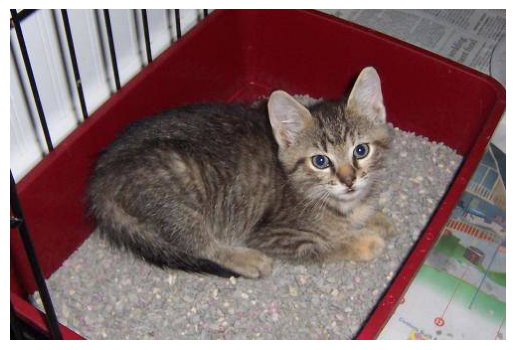

Prediction: cat (score=0.448)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


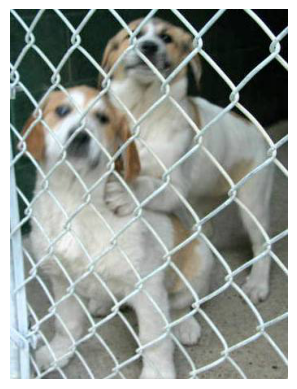

Prediction: dog (score=0.868)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


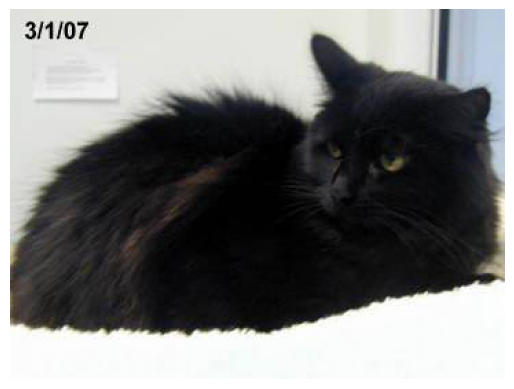

Prediction: cat (score=0.000)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


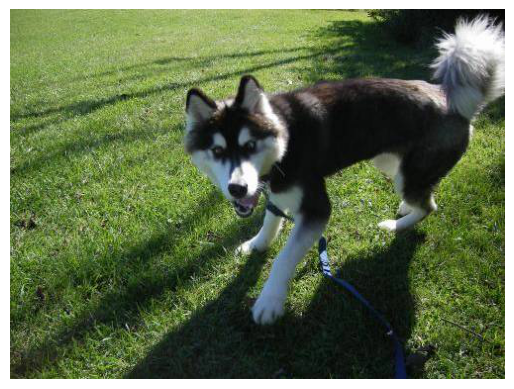

Prediction: dog (score=0.996)


In [208]:
def classifyimage(imagepath,model):
    """
    Small helper to classify a single image file using the trained model.
    """
    # Load image and resize to 64x64 to match the model input    
    test_image = load_img(imagepath, target_size = (64, 64))

    # Add batch dimension: shape becomes (1, 64, 64, 3)    
    test_image = np.expand_dims(test_image, axis = 0)

    # Model outputs a probability between 0 and 1    
    result = model.predict(test_image)
    
    if result[0][0] > 0.5:
        prediction = 'dog'
    else:
        prediction = 'cat'

    # Show the original image and print the prediction
    img = mpimg.imread(imagepath)
    plt.imshow(img)
    plt.axis('off')
    plt.show()
    print(f"Prediction: {prediction} (score={result[0][0]:.3f})")

# Run the visual test on the four unseen images
classifyimage('data/catdog/cat_or_dog_1.jpg',new_model)
classifyimage('data/catdog/cat_or_dog_2.jpg',new_model)
classifyimage('data/catdog/cat_or_dog_3.jpg',new_model)
classifyimage('data/catdog/cat_or_dog_4.jpg',new_model)

### **Summary: Task 5 (Individual Task)**

For Task 5 I redesigned the CNN from Task 4 with the goal of improving generalisation and reaching the target of ~70% validation accuracy *without* the model overfitting.  
In the baseline model, training accuracy climbed extremely high (towards 0.99) while validation accuracy stayed closer to ~0.70, clear evidence of overfitting on a small dataset.
I also kept the `Rescaling(1./255)` layer from Task 4 so that all RGB pixel values stayed in a consistent 0–1 range, following Adam’s advice to always scale features for more stable gradients during training.

To address this, I introduced several targeted improvements:

**1. Data Augmentation**  
I added random flips, rotations, zooms and translations.  
This creates new variations of each training image every epoch so the model learns robust patterns rather than memorising examples.

**2. Deeper Convolutional Feature Extractor**  
I added a second Conv2D + MaxPooling block (32 → 64 filters).  
This allowed the network to extract richer and more complex visual features before flattening.

**3. Regularisation (Dropout + L2)**  
Dropout (0.5) forces the dense layer to rely on multiple pathways instead of memorising.  
L2 regularisation helps keep weights small and prevents over-complex models.

**4. Early Stopping**  
I monitored validation loss and restored the best weights (from epoch 18).  
This prevented the model from continuing into an overfitting phase.

**5. tf.data Performance Optimisation**  
I used `.cache()`, `.shuffle()` and `.prefetch(AUTOTUNE)` to improve efficiency and stabilise training.

I was also careful not to explode the parameter count with extra dense layers, keeping the CNN relatively small and in the spirit of the “10 samples per weight” rule-of-thumb Adam mentioned, rather than chasing higher accuracy with an oversized model.

**Results:**  
The improved model achieved:
- **~0.76 training accuracy**  
- **~0.75 validation accuracy**  
- **Very small train–test gap**, showing strong generalisation  
- Correct classifications on all four unseen images during the visual test

There are some small up-and-down wiggles in the accuracy and loss curves between epochs, which Adam noted is normal when using on-the-fly data augmentation, because each epoch sees slightly different transformed versions of the images.

This meets (and slightly exceeds) the requirement of achieving around 70% accuracy **without** obvious overfitting.

**A possible extension would be training using 128×128 inputs to increase fine-detail resolution (whiskers, ear edges, eye shapes), though this increases computational cost and is not required for this task.**


## **Reflection**

### How convolutional neural networks and regularisation applied to this experiment  
Across **Tasks 1–4**, I moved from manually exploring pixel values to building a full CNN capable of classifying cats and dogs. The purpose was to understand how CNNs process images, how convolution and pooling layers extract features, and how deeper layers help the network learn hierarchical visual patterns.

In **Task 1**, I created synthetic images directly from RGB arrays, treating images as numerical grids. This made it clear that operations like addition or subtraction simply combine or compare pixel intensities, which helped me understand image data at its lowest level.

In **Task 2**, I manually implemented the convolution operation. Sliding 3×3 kernels over the UL crest and observing smoothing, sharpening and edge detection made it obvious how CNN filters detect patterns. Handling padding and kernel flipping gave me insight into exactly what Keras automates.

In **Task 3**, I implemented max-pooling. I saw how reducing the spatial dimensions helps the network keep only the strongest features while discarding noise. This also made CNNs more translation-invariant and computationally lighter.

In **Task 4**, I trained the baseline CNN. The network learned quickly on the training set but clearly **overfitted**, reaching almost 0.99 training accuracy while validation accuracy stayed near 0.70. This showed that a naïve architecture can easily memorise small datasets. Throughout Tasks 4 and 5 I also kept the `Rescaling(1./255)` layer so that all image pixels remained on a stable 0–1 scale, which aligns with Adam’s general advice to always scale features in machine learning models.

---

### Understanding the learning process and controlling overfitting  
Task 5 emphasised how sensitive CNNs are to dataset size. With only ~2400 training images, it is easy for the model to overfit unless it is deliberately regularised.

To control this, I added:

- **Data augmentation** (flip, rotate, zoom, translate)  
- **Two Conv+Pool blocks** for better feature extraction  
- **Dropout** to prevent memorisation  
- **L2 regularisation** to keep weights small  
- **Early stopping** to stop training at the optimal point

These changes worked together to stabilise training.  
The training and validation accuracy curves rose at similar rates and both converged around the mid-70% range (about **0.76 training accuracy** and **0.75 validation accuracy**), with early stopping selecting epoch 18 as the best model.  
The fact that both curves stayed close showed that the model was learning general patterns instead of memorising the images.
I was also mindful of the rule-of-thumb that you ideally want many samples per weight, so I avoided adding unnecessary dense layers that would inflate the parameter count. Some fluctuation in the curves from epoch to epoch is visible, but Adam explained that this is expected when using data augmentation, so I focused more on the overall trend and the small gap between training and validation performance.

---

### Peer and moderator input  
Although Task 5 was an individual task, earlier group discussions helped shape my approach:

- Advice about padding and kernel flipping in Task 2 improved my convolution implementation.  
- Feedback about pooling windows helped me test different setups in Task 3.  
- Moderator reminders about overfitting in Task 4 guided me to include dropout, L2 and data augmentation in Task 5.
- Feedback from Richard on the forum suggested trying data augmentation and dropout to reduce overfitting in the CNN, which directly influenced my Task 5 architecture.

---

### Comparative insights  
This e-tivity connected the low-level mathematics of convolution and pooling with the higher-level convenience of Keras.  
Understanding the operations manually made the model’s behaviour during training far easier to interpret.

Task 5 demonstrated how architectural choices affect generalisation:

- More filters → Better visual features  
- Pooling → Smaller feature maps and reduced noise  
- Dropout & L2 → Lower risk of memorisation  
- Augmentation → Stronger invariance to real-world variation  
- Early stopping → Prevents wasted training and overfitting  

I also realised that deeper or larger dense layers are not always better, with small datasets, they can harm generalisation.
Overall I tried to follow a “simplest model that works” approach: start from the baseline CNN, then add only scaling, sensible augmentation and regularisation, rather than building a very deep or complex network just to push the accuracy number higher.

---

### Advantages and disadvantages  

**Advantages**
- Strong understanding of how convolution and pooling work.  
- Manual implementation made the Keras layers intuitive.  
- Augmentation and regularisation clearly reduced overfitting.  
- Early stopping selected the most generalisable model.  
- tf.data optimisation improved training efficiency.

**Disadvantages**
- CNNs are more computationally intensive than traditional ANNs.  
- Small datasets make achieving high accuracy challenging.  
- Hyperparameter tuning requires trial and error.  
- Manual convolution is slow and not scalable.

---

### What I learned  
This e-tivity linked low-level image manipulation, feature extraction and modern deep learning.  
Implementing convolution and pooling manually gave me a deeper intuition for how CNNs work internally.  
Task 5 taught me how to iteratively refine a model with small, logical changes rather than guessing randomly.

By combining augmentation, regularisation and a slightly deeper architecture, I achieved the required ~70%+ validation accuracy without overfitting.

---

### Summary  
Beginning with raw pixel operations, I built up the full pipeline of a convolutional neural network.  
After resolving severe overfitting in the baseline model, I improved generalisation through augmentation, dropout, L2, and a second convolution block.  
The final model reached **~75% validation accuracy** with training accuracy at a similar level, achieving strong performance without memorising the data.

This e-tivity demonstrated the complete CNN workflow:  
**images → convolution → pooling → feature extraction → classifier → evaluation → refinement.**
